# Apsidal Precession Calculator
Computes observed, GR, classical (tidal+rotational), and third-body precession rates for a TESS eclipsing binary.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

import lightkurve as lk
import pandas as pd
import astropy.constants as const
import astropy.units as u
from astroquery.mast import Catalogs
import requests
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad

## 1  User Inputs
Edit everything in this cell before running the notebook.

In [92]:
from EBP_sweep import EclipsingBinaryTarget, config, load
config.OUTPUT_DIR = "NEW_RUN2"

# ── Target ────────────────────────────────────────────────────────────────────
TIC_ID   = 'TIC 343127696'
target = load(TIC_ID)
assert target is not None, "Failed to load target"

In [93]:
OC_FILE  = f'{config.OUTPUT_DIR}/Data/OC_txtfiles/TIC{TIC_ID[4:]}_OCwErr_new.txt'

oc = target.oc
bi_pri, bi_sec = oc["best_index_primary"], oc["best_index_secondary"]

# ── Periods (days) ────────────────────────────────────────────────────────────
PRIM_P, PRIM_P_ERR  =  oc['P_primary_new'],   oc['pri_uncerts'][bi_pri]
SEC_P,  SEC_P_ERR   =  oc['P_secondary_new'], oc['sec_uncerts'][bi_sec]


In [94]:

# ── Periods (days) ────────────────────────────────────────────────────────────
# PRIM_P,    PRIM_P_ERR  = 4.672293251, 0.000983506
# SEC_P,     SEC_P_ERR   = 4.672286978, 0.000695663

# ── Interior love number k (Kostov et al. 2021 assumption) ───────────────────
K_LOVE = 0.01

# ── Eker et al. (2018) mass regime ───────────────────────────────────────────
# 'high'  : M > ~1.5 Msun  (quadratic log Teff – log M relation)
# 'mid'   : 1.05 < M <= 2.4 Msun   (a=4.329, b=0.010)
# 'low'   : 0.72 < M <= 1.05 Msun  (a=5.743, b=-0.007)
# 'vlow'  : 0.45 < M <= 0.72 Msun  (a=4.572, b=-0.102)
MASS_REGIME = 'mid'


## 2  Physical Constants

In [95]:
SIGMA_SB = const.sigma_sb.to(u.Lsun / (u.Rsun**2 * u.K**4)).value
G        = const.G.to(u.Rsun**3 / (u.Msun * u.day**2)).value


## 3  Helper Functions

In [96]:
# ── Stellar parameters (Eker et al. 2018) ─────────────────────────────────────

def get_mass(Teff, Teff_err, regime='high'):
    """
    Return (M, M_err) in solar masses.

    regime='high'  inverts the quadratic log Teff – log M relation (M > ~1.5 Msun).
    Other regimes invert log L = a log M + b using Stefan-Boltzmann for log L.
    """
    _REGIMES = {
        'mid':  (4.329,  0.010),
        'low':  (5.743, -0.007),
        'vlow': (4.572, -0.102),
    }
    if regime == 'high':
        a, b, c = -0.17, 0.888, 3.671 - np.log10(Teff)
        disc = np.sqrt(b**2 - 4*a*c)
        x    = (-b + disc) / (2*a)
        M    = 10**x
        M_err = max(M / (Teff * disc) * Teff_err, 0.1)
    else:
        a_coeff, b_coeff = _REGIMES[regime]
        log_L = np.log10(4 * np.pi * Teff**4 * SIGMA_SB)
        M     = 10**((log_L - b_coeff) / a_coeff)
        M_err = max(abs(4.0 / (a_coeff * Teff)) * M * Teff_err, 0.1)
    return M, M_err


def get_lum(M, M_err):
    """Return (L, L_err) in solar luminosities (Eker et al. 2018 piecewise ML relation)."""
    table = [
        (0.179, 0.45,  2.028, -0.976),
        (0.45,  0.72,  4.572, -0.102),
        (0.72,  1.05,  5.743, -0.007),
        (1.05,  2.4,   4.329,  0.010),
        (2.4,   7.0,   3.967,  0.093),
        (7.0,  31.0,   2.865,  1.105),
    ]
    for M_lo, M_hi, a, b in table:
        if M_lo < M <= M_hi:
            L     = 10**(a * np.log10(M) + b)
            L_err = L * (a / M) * M_err
            return L, L_err
    raise ValueError(f"Mass {M:.3f} Msun outside Eker et al. (2018) range.")


def teff2_from_depths(Teff1, Teff1_err, D1, D1_err, D2, D2_err):
    """Estimate Teff2 from eclipse depth ratio, assuming blackbody emission."""
    Teff2     = (D2 / D1)**0.25 * Teff1
    var       = (Teff1_err/Teff1)**2 + (D2_err/(4*D2))**2 + (D1_err/(4*D1))**2
    Teff2_err = Teff2 * np.sqrt(var)
    return Teff2, Teff2_err


# ── Orbital mechanics ──────────────────────────────────────────────────────────

def semimajor_axis(M1, M1_err, M2, M2_err, P, P_err):
    """Kepler's third law → (a [Rsun], a_err [Rsun])."""
    a     = ((G * P**2 * (M1+M2)) / (4*np.pi**2))**(1/3)
    a_err = a * np.sqrt((2/3 * P_err/P)**2 + (1/3)**2*(M1_err**2+M2_err**2)/(M1+M2)**2)
    return a, a_err


# ── Precession rates ───────────────────────────────────────────────────────────

def omega_dot_gr(M1, M1_err, M2, M2_err, P, P_err, e):
    """GR apsidal precession (deg/cycle) and uncertainty."""
    od    = 5.447127276e-4 / (1 - e**2) * ((M1+M2)/P)**(2/3)
    S_err = np.sqrt(M1_err**2 + M2_err**2)
    od_err = od * np.sqrt(4/9 * ((S_err/(M1+M2))**2 + (P_err/P)**2))
    return od, od_err


def omega_dot_classical(M1, M1_err, M2, M2_err,
                        L1, L1_err, L2, L2_err,
                        Teff1, Teff2, a, e, k):
    """
    Classical (tidal + rotational) apsidal precession (deg/cycle).
    Assumes synchronous rotation.  Uncertainty propagated through L1, L2.
    """
    R1, R2 = (np.sqrt(L / (4*np.pi*T**4*SIGMA_SB)) for L, T in [(L1,Teff1),(L2,Teff2)])
    r1, r2 = R1/a, R2/a
    e2     = e**2
    f_tid  = 1 + 1.5*e2 + 0.125*e2**2
    f_rot  = 1 / (1-e)**2

    c_sum = (r1**5*f_rot*(1+M2/M1) + 15*r1**5*f_tid*M2/(1-e2)**5
           + r2**5*f_rot*(1+M1/M2) + 15*r2**5*f_tid*M1/(1-e2)**5)
    od = 360 * k * c_sum

    # Error via L derivatives: R ∝ L^(1/2), r ∝ L^(1/2), r^5 ∝ L^(5/2)
    C1  = 1/np.sqrt(4*np.pi*SIGMA_SB*Teff1**4)
    C2  = 1/np.sqrt(4*np.pi*SIGMA_SB*Teff2**4)
    A1  = (C1/a)**5 * (f_rot*(1+M2/M1) + 15*f_tid*M2/(1-e2)**5)
    A2  = (C2/a)**5 * (f_rot*(1+M1/M2) + 15*f_tid*M1/(1-e2)**5)
    pref   = 360 * k * 2.5
    od_err = np.sqrt((pref*A1*L1**1.5*L1_err)**2 + (pref*A2*L2**1.5*L2_err)**2)
    return od, od_err


# ── Light curve flattening ─────────────────────────────────────────────────────

def flatten_by_sector(lc, P):
    """Flatten each TESS sector separately, masking both eclipses before fitting."""
    flat_list = []
    for sector in np.unique(lc.sector):
        slc  = lc[lc.sector == sector]
        span = slc.time.value[-1] - slc.time.value[0]
        if len(slc.flux.value) < 3 or np.all(np.isnan(slc.flux.value)) or span < 0.5*P:
            continue
        bls_p  = slc.to_periodogram(method='bls', minimum_period=0.9*P, maximum_period=1.1*P)
        mask_p = bls_p.get_transit_mask(period=P, transit_time=bls_p.transit_time_at_max_power,
                                        duration=3.5*bls_p.duration_at_max_power)
        bls_s  = slc[~mask_p].to_periodogram(method='bls', minimum_period=0.9*P, maximum_period=1.1*P)
        mask_s = bls_p.get_transit_mask(period=P, transit_time=bls_s.transit_time_at_max_power,
                                        duration=3.5*bls_s.duration_at_max_power)
        window = int(1 / np.median(np.diff(slc.time.value)))
        flat, _ = slc.flatten(window_length=window, sigma=1,
                              mask=mask_p|mask_s, return_trend=True)
        flat_list.append(flat)
    if not flat_list:
        raise RuntimeError("No usable sectors after flattening.")
    return flat_list[0].append(flat_list[i+1] for i in range(len(flat_list)-1))


# ── Cycle-number alignment ─────────────────────────────────────────────────────

def find_reference_epochs(prim_times, sec_times, P_avg):
    """
    Find the pair (prim_times[i], sec_times[j]) that are in the same orbital
    cycle (|Δt| < P_avg) by checking the first few entries of each array.
    Returns (ref_prim, ref_sec) or raises RuntimeError.
    """
    for i in range(min(4, len(prim_times))):
        for j in range(min(4, len(sec_times))):
            if abs(prim_times[i] - sec_times[j]) < P_avg:
                return prim_times[i], sec_times[j]
    raise RuntimeError(
        "Could not auto-align primary/secondary epochs. "
        "Inspect the eclipse tables and set INITIAL_PRIM_IDX/INITIAL_SEC_IDX manually."
    )

def get_teff_exofop(tic_id):
    """
    Query ExoFOP-TESS for stellar parameters.
    tic_id can be 'TIC 115396972' or just '115396972'.
    Returns (Teff, Teff_err) or (nan, nan) if not found.
    """
    tic_num = str(tic_id).replace('TIC', '').strip()
    url     = f"https://exofop.ipac.caltech.edu/tess/target.php?id={tic_num}&json"

    try:
        r    = requests.get(url, timeout=10)
        data = r.json()

        # Stellar parameters live under 'stellar_parameters'
        # There can be multiple entries (different sources) — take the first non-null Teff
        for entry in data.get('stellar_parameters', []):
            teff     = entry.get('teff')
            teff_err = entry.get('teff_e')
            if teff not in (None, '', 'null'):
                return float(teff), float(teff_err) if teff_err else np.nan
    except Exception as e:
        print(f"  ExoFOP query failed: {e}")

    return np.nan, np.nan

## 4  Load Eclipse Timing Data and Query TIC

In [97]:
P_avg = (PRIM_P + SEC_P) / 2
P_err = (PRIM_P_ERR + SEC_P_ERR) / 2


In [120]:
print(f"Querying Teff for {TIC_ID} …")

cat       = Catalogs.query_object(TIC_ID, catalog="TIC", radius=0.0001).to_pandas()
Teff1     = float(cat["Teff"].iloc[0])
Teff1_err = float(cat["e_Teff"].iloc[0])
source    = 'TIC'

if np.isnan(Teff1):
        print("  TIC Teff is NaN — trying Gaia DR2 …")

        ra, dec = float(cat["ra"].iloc[0]), float(cat["dec"].iloc[0])
        coord   = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg))
        radius = u.Quantity(0.001, u.deg)
    
        cone_job = Gaia.cone_search_async(
        coordinate=coord, 
        radius=radius, 
        table_name='gaiadr2.gaia_source'
        )

        results = cone_job.get_results()
        Teff1 = results['teff_val'].value[0]
        Teff1_err = (abs(Teff1 - results['teff_percentile_lower'].value[0]) + abs(results['teff_percentile_upper'].value[0] - Teff1)) / 2

print(f"  Teff1 = {Teff1:.0f} ± {Teff1_err:.0f} K  ({source})")



Querying Teff for TIC 343127696 …
  TIC Teff is NaN — trying Gaia DR2 …
INFO: Query finished. [astroquery.utils.tap.core]
  Teff1 = 5824 ± 100 K  (TIC)


In [98]:
# OC timing file
df = pd.read_csv(OC_FILE, header=0, skiprows=[1])
df.columns = df.columns.str.strip().str.lstrip('#').str.strip()   # strip '# ' artefact

primary   = df[df['flag'] == 0].reset_index(drop=True)
secondary = df[df['flag'] == 1].reset_index(drop=True)

print(f"\nPrimary eclipses:   {len(primary)}")
print(f"Secondary eclipses: {len(secondary)}")


Primary eclipses:   30
Secondary eclipses: 29


Inspect the tables below to confirm `INITIAL_*_IDX` and `FINAL_*_IDX` are reasonable.

In [99]:
primary

,eclipse_time,eclipse_time_err,OC,flag
0,1742.672540,0.001432,0.000000,0
1,1752.019669,0.000522,3.684139,0
2,1756.690612,0.000753,1.749714,0
3,1770.706769,0.000460,0.742531,0
4,1775.377636,0.000605,-1.299917,0
5,1780.051247,0.000763,0.609192,0
6,1784.724675,0.000675,2.254149,0
7,2826.651512,0.000323,12.559463,0
8,2831.323509,0.000174,12.143887,0
9,2835.996853,0.000221,13.666911,0


In [100]:
secondary

,eclipse_time,eclipse_time_err,OC,flag
0,1740.503965,0.000388,0.000000,1
1,1745.175818,0.000717,-0.623016,1
2,1754.522269,0.000836,2.083672,1
3,1759.196735,0.000947,5.223765,1
4,1768.535984,0.000600,-2.439892,1
5,1773.209272,0.000620,-0.996319,1
6,1782.551648,0.000765,-4.157169,1
7,1787.225990,0.000650,-1.196164,1
8,2829.139439,0.000271,-10.169401,1
9,2833.816562,0.000234,-3.203005,1


In [101]:
# ── Which eclipse pair to use as initial/final epoch for deco/dt ─────────────
# Indices into the primary/secondary eclipse time arrays.
# Initial pair must be in the same orbital cycle; likewise for the final pair.
# Inspect the tables printed above to choose appropriate indices.
INITIAL_PRIM_IDX, INITIAL_SEC_IDX = 0,  0
FINAL_PRIM_IDX,   FINAL_SEC_IDX   = -1, -2

## 5  Compute Δ(*e* cos ω) / d*t*

In [102]:
prim_t = primary['eclipse_time'].values
sec_t  = secondary['eclipse_time'].values

# Auto-find reference epochs for cycle-number counting
ref_prim, ref_sec = find_reference_epochs(prim_t, sec_t, P_avg)
ref_prim, ref_sec

(1742.672539730284, 1740.5039648161746)

In [103]:
prim_t = primary['eclipse_time'].values
sec_t  = secondary['eclipse_time'].values

# Auto-find reference epochs for cycle-number counting
ref_prim, ref_sec = find_reference_epochs(prim_t, sec_t, P_avg)

cycle_prim = np.round((prim_t - ref_prim) / P_avg).astype(int)
cycle_sec  = np.round((sec_t  - ref_sec)  / P_avg).astype(int)

def e_cos_omega(t_p, t_s):
    return (np.pi / (2*P_avg)) * abs(abs(t_p - t_s) - P_avg/2)

eco_initial = e_cos_omega(prim_t[INITIAL_PRIM_IDX], sec_t[INITIAL_SEC_IDX])
eco_final   = e_cos_omega(prim_t[FINAL_PRIM_IDX],   sec_t[FINAL_SEC_IDX])

delta_cycle = (
    (cycle_prim[FINAL_PRIM_IDX] - cycle_prim[INITIAL_PRIM_IDX]) +
    (cycle_sec[FINAL_SEC_IDX]   - cycle_sec[INITIAL_SEC_IDX])
) / 2

deco_dt     = abs(eco_final - eco_initial) / delta_cycle
deco_dt_err = (np.pi / (2*P_avg)) * np.sqrt(PRIM_P_ERR**2 + SEC_P_ERR**2) / delta_cycle

print(f"e cos ω  (initial) = {eco_initial:.6f}")
print(f"e cos ω  (final)   = {eco_final:.6f}")
print(f"Δ cycles           = {delta_cycle:.1f}")
print(f"d(e cosω)/dt       = {deco_dt:.4e}  ±  {deco_dt_err:.4e}  per cycle")


e cos ω  (initial) = 0.056335
e cos ω  (final)   = 0.049474
Δ cycles           = 399.0
d(e cosω)/dt       = 1.7195e-05  ±  3.3060e-09  per cycle


## 6 Measure Eclipse Geometry

Run this cell to produce the diagnostic plots, the ingress and egress are automatically gotten from 
the eclipse fitting. However, if inaccurate for some reason, update `PRIM_T1/T2`, `SEC_T1/T2`,
and the flux limits in the **User Inputs** cell until the vertical and horizontal
lines sit cleanly on ingress/egress and the eclipse floor.


In [104]:
print("Flattening by sector …")
flat_lc = flatten_by_sector(target.good_lc, P_avg)

Flattening by sector …


In [112]:
pri_params, sec_params = target.eclipse_params["pri"], target.eclipse_params["sec"]
pri_params["D"] = pri_params['rp']**2
sec_params["D"] = sec_params['rp']**2

print(f"\n{'Parameter':12s}: {'Primary':25s} | {'Secondary':25s}")
print(f"{'-'*70}")
for k in pri_params:
 print(f"{k:12s}: {str(pri_params[k]):25s} | {str(sec_params[k]):25s}")


Parameter   : Primary                   | Secondary                
----------------------------------------------------------------------
t0          : 1742.6797+/-0.0004        | 1740.5083+/-0.0006       
P           : 4.6723066+/-0.0000013     | 4.6722592+/-0.0000018    
rp          : 0.5008+/-0.0019           | 0.4728+/-0.0023          
dur         : 0.6375+/-0.0021           | 0.6886+/-0.0031          
b           : 0.403+/-0.004             | 0.446+/-0.004            
u1          : 0.88+/-0.13               | 0.00+/-0.30              
u2          : -0.87+/-0.22              | 0.1+/-0.4                
Aev         : 0.01806+/-0.00018         | 0.01307+/-0.00021        
offset      : -0.01172+/-0.00008        | -0.01552+/-0.00009       
slope       : (5.7+/-1.7)e-07           | (3.1+/-1.8)e-07          
D           : 0.2508+/-0.0019           | 0.2235+/-0.0022          


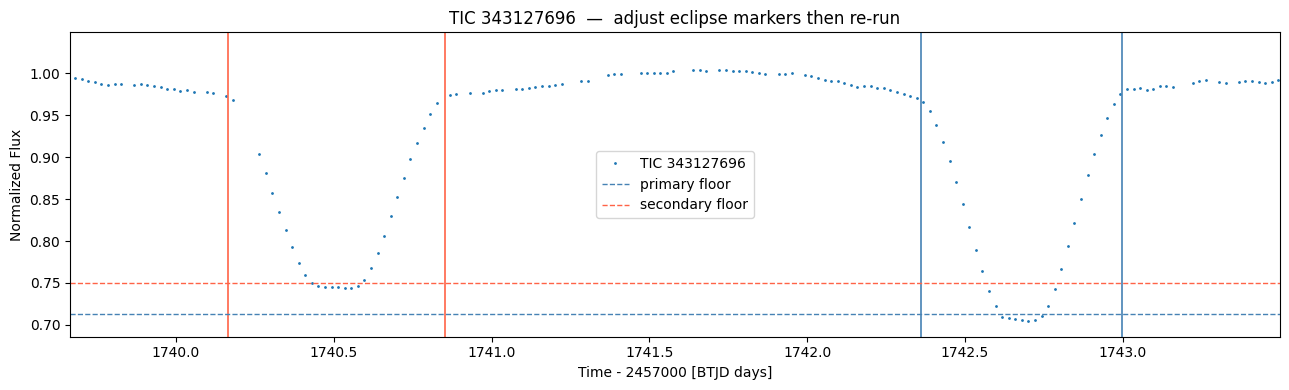

In [116]:
# ── Diagnostic plot ────────────────────────────────────────────────────────────

# ── Eclipse geometry — read from the light curve plot below ──────────────────
# Ingress / egress times (BTJD) for each eclipse
PRIM_T1, PRIM_T2 = pri_params['t0'].n - pri_params['dur'].n/2, pri_params['t0'].n + pri_params['dur'].n/2   # primary
SEC_T1,  SEC_T2  = sec_params['t0'].n - sec_params['dur'].n/2, sec_params['t0'].n + sec_params['dur'].n/2   # secondary

# Width uncertainties (days) — how precisely you can place the markers
PRIM_WIDTH_ERR = pri_params['dur'].s
SEC_WIDTH_ERR  = sec_params['dur'].s

# Out-of-eclipse and in-eclipse flux levels read from the plot
PRIM_FLUX_MAX, PRIM_FLUX_MIN = 1, 1 - pri_params["D"].n - 2*pri_params["Aev"].n
SEC_FLUX_MAX,  SEC_FLUX_MIN  = 1, 1 - sec_params["D"].n - 2*sec_params["Aev"].n

# Depth uncertainties
PRIM_DEPTH_ERR = pri_params["D"].s
SEC_DEPTH_ERR  = sec_params["D"].s


fig, ax = plt.subplots(figsize=(13, 4))
flat_lc.plot(linestyle='', marker='.', ms=2, ax=ax)

for t, c in [(PRIM_T1, 'steelblue'), (PRIM_T2, 'steelblue'),
             (SEC_T1,  'tomato'),    (SEC_T2,  'tomato')]:
    ax.axvline(t, color=c, lw=1.2)
for y, c, lbl in [(PRIM_FLUX_MIN, 'steelblue', 'primary floor'),
                  (SEC_FLUX_MIN,  'tomato',    'secondary floor')]:
    ax.axhline(y, color=c, lw=1, ls='--', label=lbl)

ax.legend(fontsize=10)
ax.set_title(f"{TIC_ID}  —  adjust eclipse markers then re-run")
plt.tight_layout()
plt.xlim(min(PRIM_T1, SEC_T1) - 0.5, max(PRIM_T2, SEC_T2) + 0.5)
plt.show()

In [115]:
# # ── Diagnostic plot ────────────────────────────────────────────────────────────

# # ── Eclipse geometry — read from the light curve plot below ──────────────────
# # Ingress / egress times (BTJD) for each eclipse
# PRIM_T1, PRIM_T2 = 3606.62, 3607.25   # primary
# SEC_T1,  SEC_T2  = 3609.06, 3609.75   # secondary

# # Width uncertainties (days) — how precisely you can place the markers
# PRIM_WIDTH_ERR = 0.005
# SEC_WIDTH_ERR  = 0.005

# # Out-of-eclipse and in-eclipse flux levels read from the plot
# PRIM_FLUX_MAX, PRIM_FLUX_MIN = 1.000, 0.715
# SEC_FLUX_MAX,  SEC_FLUX_MIN  = 1.000, 0.755

# # Depth uncertainties
# PRIM_DEPTH_ERR = 0.005
# SEC_DEPTH_ERR  = 0.005

# fig, ax = plt.subplots(figsize=(13, 4))
# flat_lc.plot(linestyle='', marker='.', ms=2, ax=ax)

# for t, c in [(PRIM_T1, 'steelblue'), (PRIM_T2, 'steelblue'),
#              (SEC_T1,  'tomato'),    (SEC_T2,  'tomato')]:
#     ax.axvline(t, color=c, lw=1.2)
# for y, c, lbl in [(PRIM_FLUX_MIN, 'steelblue', 'primary floor'),
#                   (SEC_FLUX_MIN,  'tomato',    'secondary floor')]:
#     ax.axhline(y, color=c, lw=1, ls='--', label=lbl)

# ax.legend(fontsize=10)
# ax.set_title(f"{TIC_ID}  —  adjust eclipse markers then re-run")
# plt.tight_layout()
# plt.xlim(3606, 3610)
# plt.show()

## 7  Observed Precession Rate ω̇$_{obs}$

In [121]:
theta_1 = PRIM_T2 - PRIM_T1   # primary eclipse width (days)
theta_2 = SEC_T2  - SEC_T1    # secondary eclipse width (days)
theta_1, theta_2

(0.6375255300117715, 0.6886187694008186)

In [122]:
theta_1 = PRIM_T2 - PRIM_T1   # primary eclipse width (days)
theta_2 = SEC_T2  - SEC_T1    # secondary eclipse width (days)
D1      = pri_params["D"].n
D2      = sec_params["D"].n

e_sin_omega = abs((theta_1 - theta_2) / (theta_1 + theta_2))
e_cos_omega = eco_initial
e           = np.sqrt(e_sin_omega**2 + e_cos_omega**2)
sin_omega   = e_sin_omega / e

omega_dot_obs = (deco_dt / e) / sin_omega   # rad / cycle

# Uncertainty
e_sin_omega_err = (2 / (theta_1+theta_2)**2) * np.sqrt(
    (theta_2*PRIM_WIDTH_ERR)**2 + (theta_1*SEC_WIDTH_ERR)**2
)
omega_dot_obs_err = np.sqrt(deco_dt_err**2 + (e_sin_omega_err/e)**2) * omega_dot_obs

# Convert to milli-deg / cycle for display
to_mdeg = 180/np.pi / 1e-3
print(f"e sin ω         = {e_sin_omega:.6f}")
print(f"e cos ω         = {e_cos_omega:.6f}")
print(f"e               = {e:.6f}")
print(f"ω̇_obs  = {omega_dot_obs*to_mdeg:.4f}  ±  {omega_dot_obs_err*to_mdeg:.4f}  mdeg/cycle")


e sin ω         = 0.038528
e cos ω         = 0.056335
e               = 0.068250
ω̇_obs  = 25.5717  ±  1.0447  mdeg/cycle


## 8  Stellar Parameters

In [123]:
Teff2, Teff2_err = teff2_from_depths(Teff1, Teff1_err, D1, PRIM_DEPTH_ERR, D2, SEC_DEPTH_ERR)
print(f"Teff1 = {Teff1:.0f} ± {Teff1_err:.0f} K")
print(f"Teff2 = {Teff2:.0f} ± {Teff2_err:.0f} K")

M1, M1_err = get_mass(Teff1, Teff1_err, regime=MASS_REGIME)
M2, M2_err = get_mass(Teff2, Teff2_err, regime=MASS_REGIME)
print(f"\nM1 = {M1:.4f} ± {M1_err:.4f} Msun")
print(f"M2 = {M2:.4f} ± {M2_err:.4f} Msun")

L1, L1_err = get_lum(M1, M1_err)
L2, L2_err = get_lum(M2, M2_err)
print(f"L1 = {L1:.4f} ± {L1_err:.4f} Lsun")
print(f"L2 = {L2:.4f} ± {L2_err:.4f} Lsun")

a_rsun, a_rsun_err = semimajor_axis(M1, M1_err, M2, M2_err, P_avg, P_err)
a_au = (a_rsun * u.Rsun).to(u.AU).value
print(f"\na  = {a_rsun:.4f} ± {a_rsun_err:.4f} Rsun  ({a_au:.5f} AU)")


Teff1 = 5824 ± 100 K
Teff2 = 5659 ± 98 K

M1 = 1.0030 ± 0.1000 Msun
M2 = 0.9766 ± 0.1000 Msun
L1 = 1.0009 ± 0.5731 Lsun
L2 = 0.8591 ± 0.5052 Lsun

a  = 14.7679 ± 0.3517 Rsun  (0.06868 AU)


## 9  GR Precession Rate ω̇$_{GR}$

In [124]:
od_gr, od_gr_err = omega_dot_gr(M1, M1_err, M2, M2_err, P_avg, P_err, e)
print(f"ω̇_GR  = {od_gr/1e-3:.4f}  ±  {od_gr_err/1e-3:.4f}  mdeg/cycle")


ω̇_GR  = 0.3087  ±  0.0147  mdeg/cycle


## 10  Classical Precession Rate ω̇$_{cl}$ (tidal + rotational)

In [125]:
od_cl, od_cl_err = omega_dot_classical(
    M1, M1_err, M2, M2_err,
    L1, L1_err, L2, L2_err,
    Teff1, Teff2, a_rsun, e, K_LOVE,
)
print(f"ω̇_cl  = {od_cl/1e-3:.4f}  ±  {od_cl_err/1e-3:.4f}  mdeg/cycle")


ω̇_cl  = 0.1579  ±  0.1619  mdeg/cycle


## 11  Third-Body Precession Rate ω̇$_{3rd}$

In [126]:
# All quantities in mdeg/cycle from here
od_obs_mdeg = omega_dot_obs     * (180/np.pi) / 1e-3
od_obs_err_mdeg = omega_dot_obs_err * (180/np.pi) / 1e-3
od_gr_mdeg,  od_gr_err_mdeg  = od_gr  / 1e-3, od_gr_err  / 1e-3
od_cl_mdeg,  od_cl_err_mdeg  = od_cl  / 1e-3, od_cl_err  / 1e-3

od_3rd_mdeg     = od_obs_mdeg - od_gr_mdeg - od_cl_mdeg
od_3rd_err_mdeg = np.sqrt(od_obs_err_mdeg**2 + od_gr_err_mdeg**2 + od_cl_err_mdeg**2)

print(f"ω̇_obs  = {od_obs_mdeg:.4f}  ±  {od_obs_err_mdeg:.4f}  mdeg/cycle")
print(f"ω̇_GR   = {od_gr_mdeg:.4f}   ±  {od_gr_err_mdeg:.4f}  mdeg/cycle")
print(f"ω̇_cl   = {od_cl_mdeg:.4f}   ±  {od_cl_err_mdeg:.4f}  mdeg/cycle")
print(f"─────────────────────────────────────────────────")
print(f"ω̇_3rd  = {od_3rd_mdeg:.4f}  ±  {od_3rd_err_mdeg:.4f}  mdeg/cycle")


ω̇_obs  = 25.5717  ±  1.0447  mdeg/cycle
ω̇_GR   = 0.3087   ±  0.0147  mdeg/cycle
ω̇_cl   = 0.1579   ±  0.1619  mdeg/cycle
─────────────────────────────────────────────────
ω̇_3rd  = 25.1051  ±  1.0573  mdeg/cycle


## 12  Plots

### O-C Diagram

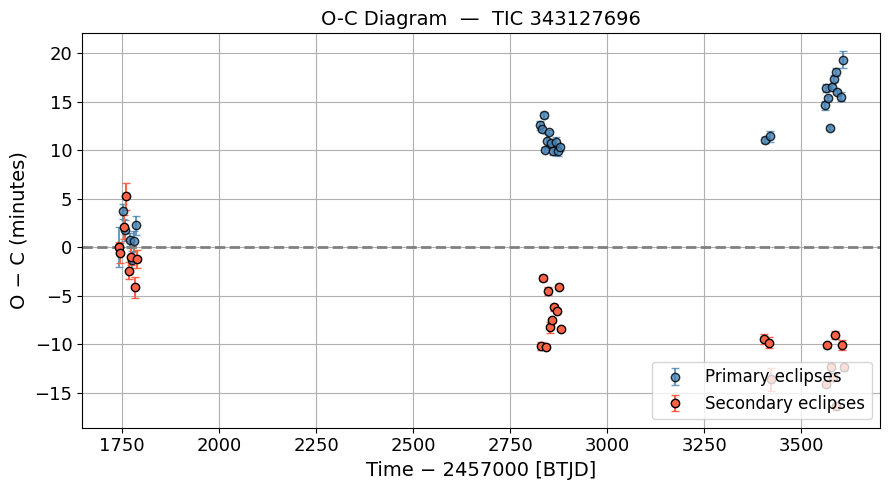

In [127]:
fig, ax = plt.subplots(figsize=(9, 5))
kw = dict(fmt='o', capsize=3, markeredgecolor='k')
ax.errorbar(primary['eclipse_time'],   primary['OC'],
            yerr=primary['eclipse_time_err']*24*60,
            color='steelblue', ecolor='steelblue', alpha=0.8,
            label='Primary eclipses', **kw)
ax.errorbar(secondary['eclipse_time'], secondary['OC'],
            yerr=secondary['eclipse_time_err']*24*60,
            color='tomato', ecolor='tomato',
            label='Secondary eclipses', **kw)
ax.axhline(0, color='gray', ls='--', lw=2)
ax.set_xlabel('Time − 2457000 [BTJD]', fontsize=14)
ax.set_ylabel('O − C (minutes)', fontsize=14)
ax.set_title(f'O-C Diagram  —  {TIC_ID}', fontsize=14)
ax.tick_params(labelsize=13)
ax.legend(fontsize=12, loc='lower right')
ax.grid(True)
plt.tight_layout()
# plt.savefig(f'../Figures/OC_plots/TIC{TIC_ID[4:]}_OC.png', dpi=250, bbox_inches='tight')
plt.show()


### Third-Body Mass vs. Semimajor Axis

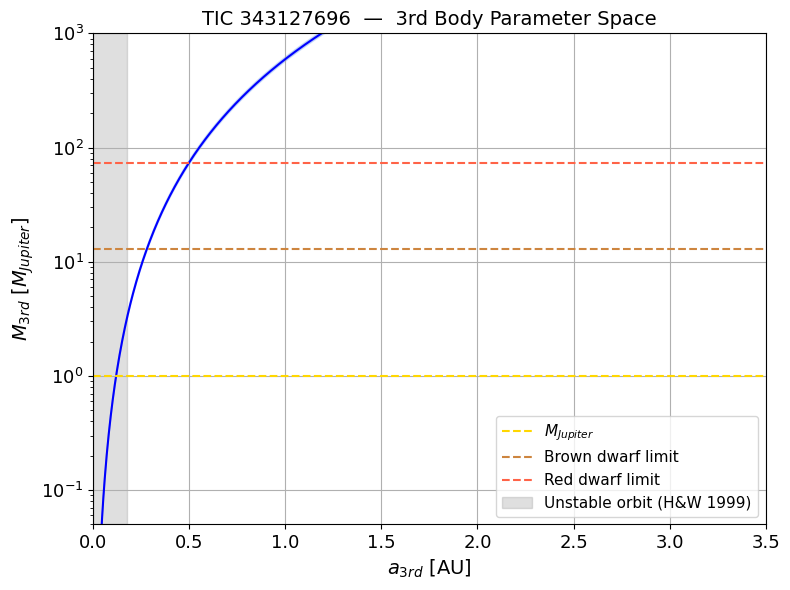

In [128]:
od_3rd = od_3rd_mdeg * 1e-3   # mdeg/cycle → deg/cycle

a3_au   = np.linspace(0, 3.5, 1000)
K_curve = (4 * (M1+M2) * a3_au**3) / (3 * 360 * a_au**3)
M3_msun = K_curve * od_3rd
M3_mjup = (M3_msun * u.Msun).to(u.Mjup).value
M3_err_mjup = K_curve * od_3rd_err_mdeg * 1e-3 * (u.Msun).to(u.Mjup) #.value

# Holman & Wiegert (1999) critical semimajor axis
mu      = M2 / (M1 + M2)
a_crit  = a_au * (1.60 + 5.10*e - 2.22*e**2 + 4.12*mu
                  - 4.27*e*mu - 5.09*mu**2 + 4.61*e**2*mu**2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(a3_au, M3_mjup, 'b-')
ax.fill_between(a3_au,
                np.maximum(M3_mjup - M3_err_mjup, 1e-3),
                M3_mjup + M3_err_mjup,
                alpha=0.3, color='cornflowerblue')

ax.axhline(1,     color='gold',   ls='--', label='$M_{Jupiter}$')
ax.axhline(13,    color='peru',   ls='--', label='Brown dwarf limit')
ax.axhline(73.33, color='tomato', ls='--', label='Red dwarf limit')
ax.fill_betweenx([5e-2, 1e3], 0, a_crit,
                 alpha=0.25, color='grey', label='Unstable orbit (H&W 1999)')

ax.set_yscale('log')
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2,10), numticks=100))
ax.set_xlim(0, 3.5)
ax.set_ylim(5e-2, 1e3)
ax.set_xlabel('$a_{3rd}$ [AU]', fontsize=14)
ax.set_ylabel('$M_{3rd}$ [$M_{Jupiter}$]', fontsize=14)
ax.set_title(f'{TIC_ID}  —  3rd Body Parameter Space', fontsize=14)
ax.tick_params(labelsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True)
plt.tight_layout()
# plt.savefig(f'../Figures/MassSemimajor/TIC{TIC_ID[4:]}_3rd.png', dpi=250, bbox_inches='tight')
plt.show()


## 13  Summary

In [129]:
print(f"{'─'*50}")
print(f"  {TIC_ID}")
print(f"{'─'*50}")
print(f"  Teff1          = {Teff1:.0f} ± {Teff1_err:.0f} K")
print(f"  Teff2          = {Teff2:.0f} ± {Teff2_err:.0f} K")
print(f"  M1             = {M1:.3f} ± {M1_err:.3f} Msun")
print(f"  M2             = {M2:.3f} ± {M2_err:.3f} Msun")
print(f"  a              = {a_au:.5f} AU")
print(f"  e              = {e:.6f}")
print(f"{'─'*50}")
print(f"  ω̇_obs  = {od_obs_mdeg:+.4f}  ±  {od_obs_err_mdeg:.4f}  mdeg/cycle")
print(f"  ω̇_GR   = {od_gr_mdeg:+.4f}   ±  {od_gr_err_mdeg:.4f}  mdeg/cycle")
print(f"  ω̇_cl   = {od_cl_mdeg:+.4f}   ±  {od_cl_err_mdeg:.4f}  mdeg/cycle")
print(f"  ω̇_3rd  = {od_3rd_mdeg:+.4f}  ±  {od_3rd_err_mdeg:.4f}  mdeg/cycle")
print(f"{'─'*50}")


──────────────────────────────────────────────────
  TIC 343127696
──────────────────────────────────────────────────
  Teff1          = 5824 ± 100 K
  Teff2          = 5659 ± 98 K
  M1             = 1.003 ± 0.100 Msun
  M2             = 0.977 ± 0.100 Msun
  a              = 0.06868 AU
  e              = 0.068250
──────────────────────────────────────────────────
  ω̇_obs  = +25.5717  ±  1.0447  mdeg/cycle
  ω̇_GR   = +0.3087   ±  0.0147  mdeg/cycle
  ω̇_cl   = +0.1579   ±  0.1619  mdeg/cycle
  ω̇_3rd  = +25.1051  ±  1.0573  mdeg/cycle
──────────────────────────────────────────────────
